# **FMN SUPPLY DATA ANALYSIS AMD INVENTORY MODELLING**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import streamlit
import joblib
import gdown
import lightgbm
import sklearn


In [4]:
print(f"streamlit=={streamlit.__version__}")
print(f"pandas=={pd.__version__}")
print(f"numpy=={np.__version__}")
print(f"joblib=={joblib.__version__}")
print(f"gdown=={gdown.__version__}")
print(f"lightgbm=={lightgbm.__version__}")
print(f"scikit-learn=={sklearn.__version__}")

streamlit==1.52.2
pandas==2.3.3
numpy==2.4.0
joblib==1.5.3
gdown==6.0.0
lightgbm==4.7.0
scikit-learn==1.8.0


In [2]:
# import demand data
spd_data = pd.read_csv('C:\\Users\\HOBS\\Data_science\\FMN\\project1_supply_chain_demand.csv')

In [3]:
spd_data.head()

,date,sku_id,category,units_sold,units_received,closing_stock,lead_time_days
0,2026-01-01,SKU-1000,Snacks,110.0,0,403.0,7
1,2026-01-02,SKU-1000,Snacks,278.0,0,125.0,7
2,2026-01-03,SKU-1000,Snacks,121.0,903,907.0,7
3,2026-01-04,SKU-1000,Snacks,75.0,0,832.0,7
4,2026-01-05,SKU-1000,Snacks,71.0,0,761.0,7


## **Explore categorical Variable**

In [4]:
spd_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4551 entries, 0 to 4550
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            4551 non-null   object 
 1   sku_id          4551 non-null   object 
 2   category        4551 non-null   object 
 3   units_sold      4461 non-null   float64
 4   units_received  4551 non-null   int64  
 5   closing_stock   4505 non-null   float64
 6   lead_time_days  4551 non-null   int64  
dtypes: float64(2), int64(2), object(3)
memory usage: 249.0+ KB


In [5]:
spd_data.isnull().sum()

date               0
sku_id             0
category           0
units_sold        90
units_received     0
closing_stock     46
lead_time_days     0
dtype: int64

In [6]:
# ceck for duplicates
spd_data.duplicated().sum()

np.int64(15)

In [7]:
# remove duplicates and null values
spd_data.drop_duplicates(inplace=True)
spd_data.dropna(inplace=True)

In [8]:
spd_data["category"].value_counts()

category
Beverages    1224
Snacks       1056
Sugar         869
Pasta         697
Flour         536
BEVERAGES       8
SNACKS          4
SUGAR           4
FLOUR           2
PASTA           1
Name: count, dtype: int64

In [9]:
# change category variables to proper case
spd_data['category'] = spd_data['category'].str.title()
spd_data["category"].value_counts()


category
Beverages    1232
Snacks       1060
Sugar         873
Pasta         698
Flour         538
Name: count, dtype: int64

Text(0, 0.5, 'Count')

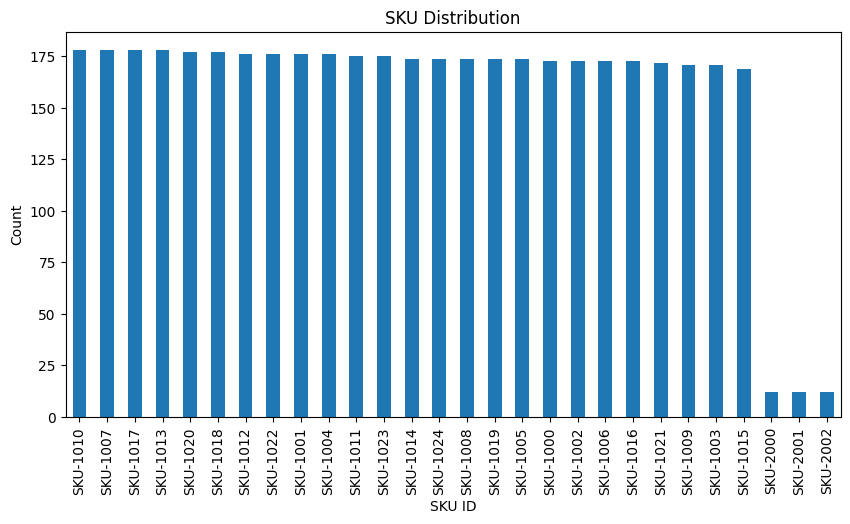

In [10]:
# splot sku distribution
spd_data['sku_id'].value_counts().plot(kind='bar', figsize=(10, 5))
plt.title('SKU Distribution')
plt.xlabel('SKU ID')
plt.ylabel('Count')

Text(0, 0.5, 'Count')

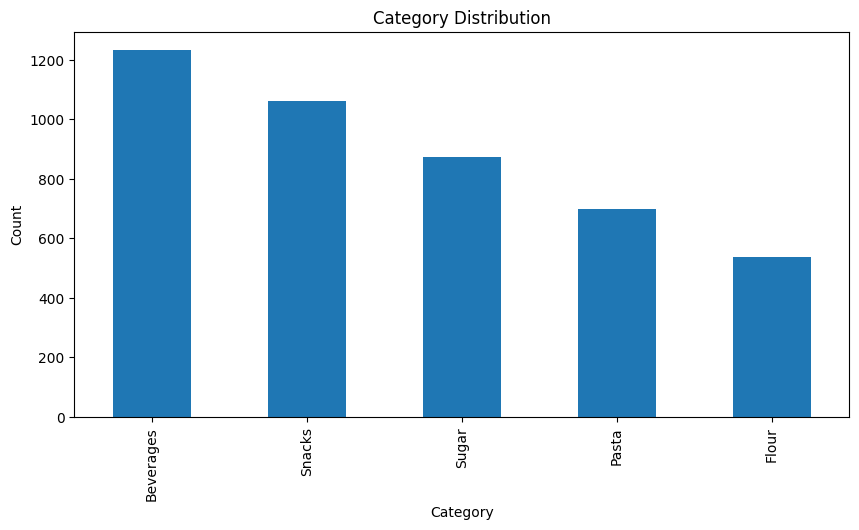

In [11]:
# Distribution by category
spd_data['category'].value_counts().plot(kind='bar', figsize=(10, 5))
plt.title('Category Distribution')
plt.xlabel('Category')
plt.ylabel('Count')

## **Explore Numerical Variables**

In [12]:
spd_data.describe()

,units_sold,units_received,closing_stock,lead_time_days
count,4401.000000,4401.000000,4401.000000,4401.000000
mean,297.437173,292.907067,3647.753011,8.910929
std,156.914080,1137.599984,3374.029224,4.048487
min,14.000000,0.000000,0.000000,3.000000
25%,185.000000,0.000000,942.000000,7.000000
50%,267.000000,0.000000,2612.000000,7.000000
75%,403.000000,0.000000,5540.000000,14.000000
max,1366.000000,10148.000000,17354.000000,14.000000


Text(0, 0.5, 'Frequency')

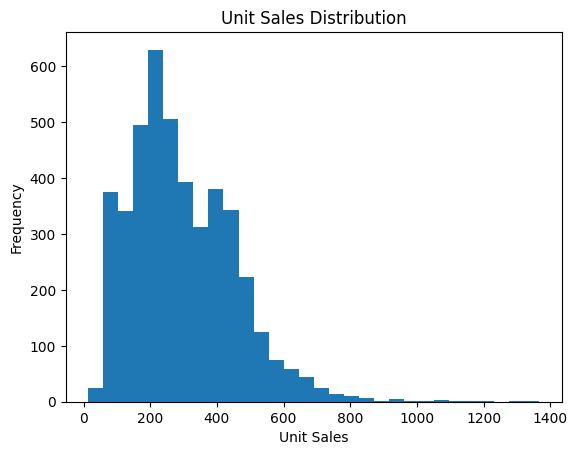

In [13]:
# distribution for unit-slsold, inits_recived, closing_stock and unit_price
plt.hist(spd_data['units_sold'], bins=30)
plt.title('Unit Sales Distribution')
plt.xlabel('Unit Sales')
plt.ylabel('Frequency')

Text(0, 0.5, 'Frequency')

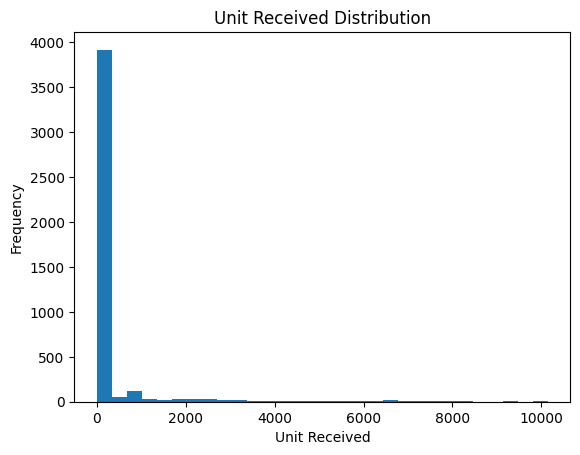

In [14]:
plt.hist(spd_data['units_received'], bins=30)
plt.title('Unit Received Distribution')
plt.xlabel('Unit Received')
plt.ylabel('Frequency')

Text(0, 0.5, 'Frequency')

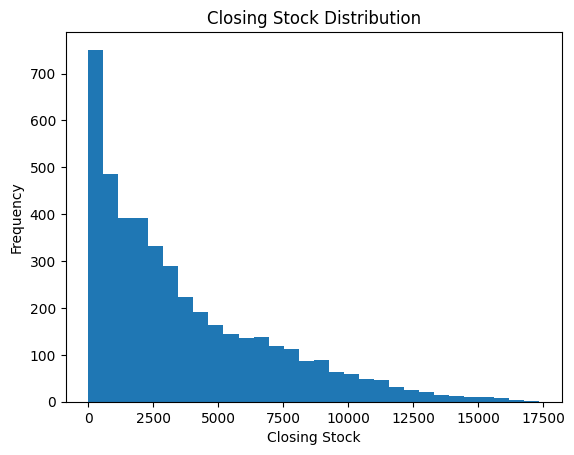

In [15]:
plt.hist(spd_data['closing_stock'], bins=30)
plt.title('Closing Stock Distribution')
plt.xlabel('Closing Stock')
plt.ylabel('Frequency')

Text(0, 0.5, 'Frequency')

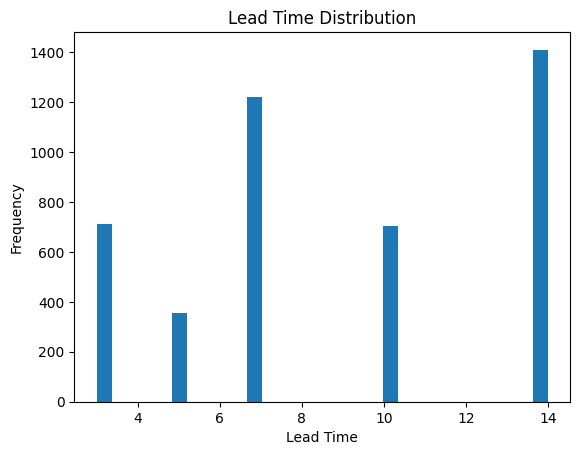

In [16]:
plt.hist(spd_data['lead_time_days'], bins=30)
plt.title('Lead Time Distribution')
plt.xlabel('Lead Time')
plt.ylabel('Frequency')

## **Feature Engineering**

In [17]:
# covert date column to date
spd_data['date'] = pd.to_datetime(spd_data['date'], format='%Y-%m-%d')

In [18]:
spd_data["date"].head()

0   2026-01-01
1   2026-01-02
2   2026-01-03
3   2026-01-04
4   2026-01-05
Name: date, dtype: datetime64[ns]

In [18]:
# sort supply data by date and sku_id
spd_df = spd_data.sort_values(by=['date', 'sku_id']).reset_index(drop=True)

In [19]:
spd_df.head()

,date,sku_id,category,units_sold,units_received,closing_stock,lead_time_days
0,2026-01-01,SKU-1000,Snacks,110.0,0,403.0,7
1,2026-01-01,SKU-1002,Sugar,245.0,0,1722.0,3
2,2026-01-01,SKU-1003,Beverages,169.0,0,1804.0,7
3,2026-01-01,SKU-1004,Beverages,286.0,0,1554.0,7
4,2026-01-01,SKU-1005,Pasta,83.0,1105,1803.0,10


In [21]:
# creating calendar features
spd_df['day'] = spd_df['date'].dt.day
spd_df['day_of_week'] = spd_df['date'].dt.dayofweek
spd_df['month'] = spd_df['date'].dt.month
spd_df['year'] = spd_df['date'].dt.year
spd_df['is_weekend'] = spd_df['day_of_week'].isin([5, 6]).astype(int)


In [22]:
#Grouped SKU Moving Averages (With Leakage Prevention & No Row Loss)
grouped = spd_df.groupby('sku_id')["units_sold"]

In [23]:
pd.DataFrame(grouped.head(10))

,units_sold
0,110.0
1,245.0
2,169.0
3,286.0
4,83.0
...,...
4316,316.0
4317,176.0
4343,238.0
4344,256.0


In [24]:
# Calculate moving averages for each SKU
spd_df['dem_ma3'] = grouped.transform(lambda x: x.shift(1).rolling(window=3, min_periods=1).mean())
spd_df['dem_ma7'] = grouped.transform(lambda x: x.shift(1).rolling(window=7, min_periods=1).mean())
spd_df['dem_ma14'] = grouped.transform(lambda x: x.shift(1).rolling(window=14, min_periods=1).mean())
spd_df['dem_ma28'] = grouped.transform(lambda x: x.shift(1).rolling(window=28, min_periods=1).mean())

In [25]:
spd_df.head(10)

,date,sku_id,category,units_sold,units_received,closing_stock,lead_time_days,day,day_of_week,month,year,is_weekend,dem_ma3,dem_ma7,dem_ma14,dem_ma28
0,2026-01-01,SKU-1000,Snacks,110.0,0,403.0,7,1,3,1,2026,0,NaN,NaN,NaN,NaN
1,2026-01-01,SKU-1002,Sugar,245.0,0,1722.0,3,1,3,1,2026,0,NaN,NaN,NaN,NaN
2,2026-01-01,SKU-1003,Beverages,169.0,0,1804.0,7,1,3,1,2026,0,NaN,NaN,NaN,NaN
3,2026-01-01,SKU-1004,Beverages,286.0,0,1554.0,7,1,3,1,2026,0,NaN,NaN,NaN,NaN
4,2026-01-01,SKU-1005,Pasta,83.0,1105,1803.0,10,1,3,1,2026,0,NaN,NaN,NaN,NaN
5,2026-01-01,SKU-1006,Sugar,579.0,0,4148.0,10,1,3,1,2026,0,NaN,NaN,NaN,NaN
6,2026-01-01,SKU-1007,Sugar,614.0,0,1748.0,14,1,3,1,2026,0,NaN,NaN,NaN,NaN
7,2026-01-01,SKU-1008,Sugar,77.0,0,291.0,5,1,3,1,2026,0,NaN,NaN,NaN,NaN
8,2026-01-01,SKU-1009,Beverages,372.0,0,2762.0,14,1,3,1,2026,0,NaN,NaN,NaN,NaN
9,2026-01-01,SKU-1010,Snacks,237.0,0,911.0,3,1,3,1,2026,0,NaN,NaN,NaN,NaN


In [26]:
spd_df.isnull().sum()

date               0
sku_id             0
category           0
units_sold         0
units_received     0
closing_stock      0
lead_time_days     0
day                0
day_of_week        0
month              0
year               0
is_weekend         0
dem_ma3           28
dem_ma7           28
dem_ma14          28
dem_ma28          28
dtype: int64

In [27]:
# demand volatility for 14 day window
spd_df['dem_vol14'] = grouped.transform(lambda x: x.shift(1).rolling(window=14, min_periods=1).std())

In [28]:
# fill boundary Nan without dropping any data
spd_df['dem_ma3'] = spd_df['dem_ma3'].fillna(
    grouped.transform(lambda x: x.expanding().mean())
).fillna(0)

spd_df['dem_ma7'] = spd_df['dem_ma7'].fillna(
    grouped.transform(lambda x: x.expanding().mean())
).fillna(0)

spd_df['dem_ma14'] = spd_df['dem_ma14'].fillna(
    grouped.transform(lambda x: x.expanding().mean())
).fillna(0)

spd_df['dem_ma28'] = spd_df['dem_ma28'].fillna(
    grouped.transform(lambda x: x.expanding().mean())
).fillna(0)


In [29]:
# fill nas in demand volatility
spd_df['dem_vol14'] = spd_df['dem_vol14'].fillna(0.0)

eps = 1e-5  # Prevents division by zero
spd_df['demand_momentum'] = (spd_df['dem_ma7'] + eps) / (spd_df['dem_ma28'] + eps)
spd_df['demand_cv'] = spd_df['dem_vol14'] / (spd_df['dem_ma14'] + eps)

In [30]:
# aggregate demand by category on daily basis
daily_cat_dem = spd_df.groupby(['category', 'date'])['units_sold'].sum().reset_index()
daily_cat_dem.rename(columns={'units_sold': 'cat_units_sold'}, inplace=True)

<Axes: xlabel='category'>

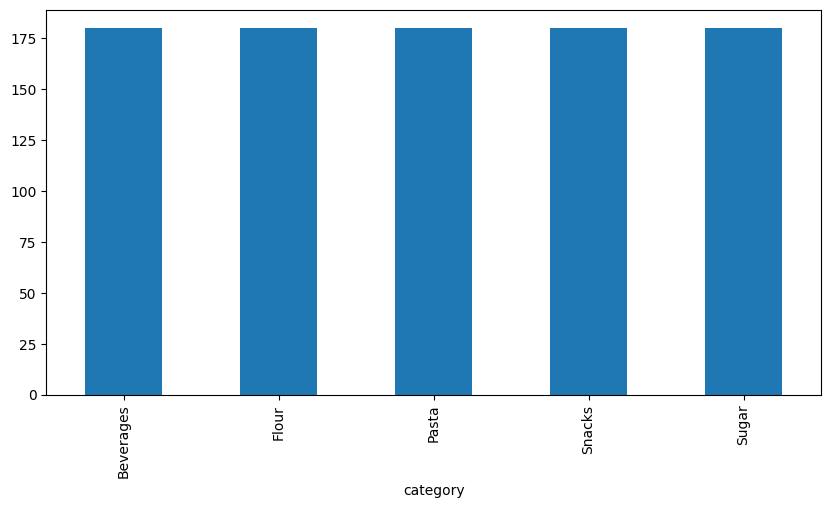

In [31]:
daily_cat_dem['category'].value_counts().plot(kind='bar', figsize=(10, 5))

In [32]:
# Merge back into main dataframe

spd_df = spd_df.merge(daily_cat_dem, on=['category', 'date'], how='left')


In [33]:
spd_df.head(10)

,date,sku_id,category,units_sold,units_received,closing_stock,lead_time_days,day,day_of_week,month,year,is_weekend,dem_ma3,dem_ma7,dem_ma14,dem_ma28,dem_vol14,demand_momentum,demand_cv,cat_units_sold
0,2026-01-01,SKU-1000,Snacks,110.0,0,403.0,7,1,3,1,2026,0,110.0,110.0,110.0,110.0,0.0,1.0,0.0,1821.0
1,2026-01-01,SKU-1002,Sugar,245.0,0,1722.0,3,1,3,1,2026,0,245.0,245.0,245.0,245.0,0.0,1.0,0.0,1683.0
2,2026-01-01,SKU-1003,Beverages,169.0,0,1804.0,7,1,3,1,2026,0,169.0,169.0,169.0,169.0,0.0,1.0,0.0,2004.0
3,2026-01-01,SKU-1004,Beverages,286.0,0,1554.0,7,1,3,1,2026,0,286.0,286.0,286.0,286.0,0.0,1.0,0.0,2004.0
4,2026-01-01,SKU-1005,Pasta,83.0,1105,1803.0,10,1,3,1,2026,0,83.0,83.0,83.0,83.0,0.0,1.0,0.0,1277.0
5,2026-01-01,SKU-1006,Sugar,579.0,0,4148.0,10,1,3,1,2026,0,579.0,579.0,579.0,579.0,0.0,1.0,0.0,1683.0
6,2026-01-01,SKU-1007,Sugar,614.0,0,1748.0,14,1,3,1,2026,0,614.0,614.0,614.0,614.0,0.0,1.0,0.0,1683.0
7,2026-01-01,SKU-1008,Sugar,77.0,0,291.0,5,1,3,1,2026,0,77.0,77.0,77.0,77.0,0.0,1.0,0.0,1683.0
8,2026-01-01,SKU-1009,Beverages,372.0,0,2762.0,14,1,3,1,2026,0,372.0,372.0,372.0,372.0,0.0,1.0,0.0,2004.0
9,2026-01-01,SKU-1010,Snacks,237.0,0,911.0,3,1,3,1,2026,0,237.0,237.0,237.0,237.0,0.0,1.0,0.0,1821.0


In [34]:
# 7-day category moving average (shifted by 1 to prevent leakage)
spd_df['cat_dem_ma7'] = (
    spd_df.groupby('category')['cat_units_sold']
    .transform(lambda x: x.shift(1).rolling(7, min_periods=1).mean())
    .fillna(spd_df['cat_units_sold'])
    .fillna(0.0)
)

# share of each SKU in its category
eps = 1e-5
spd_df['sku_category_share'] = (spd_df['dem_ma7'] + eps) / (spd_df['cat_dem_ma7'] + eps)

## **DOI and Buffer ratio features using lead_time_day, closing_stock**  and `smoothed demand dma_ma7`

In [35]:
# inventory demand whilst waiting for restock
spd_df['lead_time_dma'] = spd_df['dem_ma7'] * spd_df['lead_time_days']

In [36]:
# safety stock assumming 95% service level (z-score = 1.65 for 0.95 service level)
# calculate safety stock based on demand volatility and lead time( in case there is  a spike in demand during the lead time)
spd_df['safety_stock'] = 1.65 * np.sqrt(spd_df['lead_time_days'] * (spd_df['dem_vol14']**2))

# days of inventory coverage based on current stock and demand
spd_df['days_of_inventory'] = spd_df['closing_stock'] / (spd_df['dem_ma7'] + eps)

# lead time demand coverage 
spd_df['lead_time_cvr'] = spd_df['days_of_inventory'] / (spd_df['lead_time_days'] + eps)

#net flow
spd_df['net_flow'] = spd_df['units_received'] - spd_df['units_sold']

In [37]:
spd_df.head(10)

,date,sku_id,category,units_sold,units_received,closing_stock,lead_time_days,day,day_of_week,month,...,demand_momentum,demand_cv,cat_units_sold,cat_dem_ma7,sku_category_share,lead_time_dma,safety_stock,days_of_inventory,lead_time_cvr,net_flow
0,2026-01-01,SKU-1000,Snacks,110.0,0,403.0,7,1,3,1,...,1.0,0.0,1821.0,1821.0,0.060406,770.0,0.0,3.663636,0.523376,-110.0
1,2026-01-01,SKU-1002,Sugar,245.0,0,1722.0,3,1,3,1,...,1.0,0.0,1683.0,1683.0,0.145573,735.0,0.0,7.028571,2.342849,-245.0
2,2026-01-01,SKU-1003,Beverages,169.0,0,1804.0,7,1,3,1,...,1.0,0.0,2004.0,2004.0,0.084331,1183.0,0.0,10.674556,1.524934,-169.0
3,2026-01-01,SKU-1004,Beverages,286.0,0,1554.0,7,1,3,1,...,1.0,0.0,2004.0,2004.0,0.142715,2002.0,0.0,5.433566,0.776223,-286.0
4,2026-01-01,SKU-1005,Pasta,83.0,1105,1803.0,10,1,3,1,...,1.0,0.0,1277.0,1277.0,0.064996,830.0,0.0,21.722889,2.172287,1022.0
5,2026-01-01,SKU-1006,Sugar,579.0,0,4148.0,10,1,3,1,...,1.0,0.0,1683.0,1683.0,0.344029,5790.0,0.0,7.164076,0.716407,-579.0
6,2026-01-01,SKU-1007,Sugar,614.0,0,1748.0,14,1,3,1,...,1.0,0.0,1683.0,1683.0,0.364825,8596.0,0.0,2.846905,0.203350,-614.0
7,2026-01-01,SKU-1008,Sugar,77.0,0,291.0,5,1,3,1,...,1.0,0.0,1683.0,1683.0,0.045752,385.0,0.0,3.779220,0.755843,-77.0
8,2026-01-01,SKU-1009,Beverages,372.0,0,2762.0,14,1,3,1,...,1.0,0.0,2004.0,2004.0,0.185629,5208.0,0.0,7.424731,0.530338,-372.0
9,2026-01-01,SKU-1010,Snacks,237.0,0,911.0,3,1,3,1,...,1.0,0.0,1821.0,1821.0,0.130148,711.0,0.0,3.843882,1.281290,-237.0


## **Create Inventory Status variable**

In [38]:
# calculate reorder point
spd_df['ROP_days'] = spd_df['lead_time_days'] * (1 + spd_df['demand_cv'].clip(lower=0.1, upper=0.8))

In [39]:
#Overstock Ceiling 3X reorder point
k = 1.35
spd_df['max_stock_days'] = spd_df['ROP_days'] * k

#inventory_statuses
conditions = [
    spd_df['days_of_inventory'] < spd_df['ROP_days'],
    spd_df['days_of_inventory'] > spd_df['max_stock_days']
]
choices = ['understock', 'overstock']
spd_df['inventory_status'] = np.select(conditions, choices, default='optimal')

#at_risk_of_stockout (Early-Warning Flag: Runway is shorter than supplier delivery time)
spd_df['at_risk_of_stockout'] = (spd_df['days_of_inventory'] < spd_df['lead_time_days']).astype(int)


In [40]:
# Check the distribution of the new grounded labels
print("Class Distribution (%):")
print(spd_df['inventory_status'].value_counts(normalize=True) * 100)

print("\nEarly Warning Stockout Flag Count:")
print(spd_df['at_risk_of_stockout'].value_counts())

Class Distribution (%):
inventory_status
understock    52.942513
optimal       25.085208
overstock     21.972279
Name: proportion, dtype: float64

Early Warning Stockout Flag Count:
at_risk_of_stockout
0    2808
1    1593
Name: count, dtype: int64


<Axes: xlabel='inventory_status'>

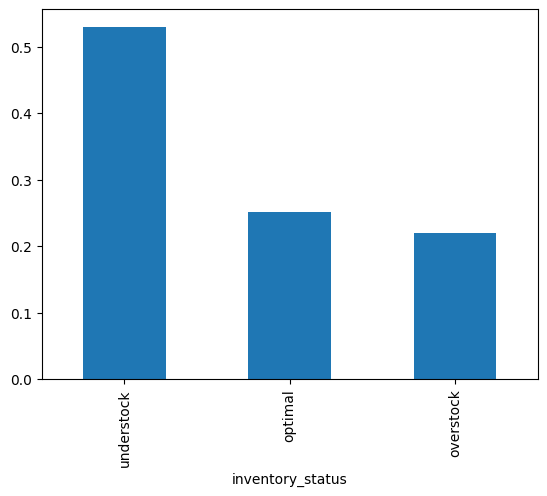

In [41]:
spd_df['inventory_status'].value_counts(normalize=True).plot(kind='bar')

In [43]:
print(spd_df[['days_of_inventory', 'lead_time_cvr', 'demand_cv']].describe(
    percentiles=[0.05, 0.15, 0.25, 0.5, 0.75, 0.85, 0.95]
))

       days_of_inventory  lead_time_cvr    demand_cv
count        4401.000000    4401.000000  4401.000000
mean           11.308110       1.190258     0.247460
std             7.891616       0.606173     0.099942
min             0.000000       0.000000     0.000000
5%              0.000000       0.000000     0.107518
15%             2.536286       0.553473     0.154187
25%             4.899551       0.809630     0.186315
50%            10.434441       1.209023     0.238289
75%            16.555524       1.612594     0.297366
85%            20.063071       1.828058     0.339258
95%            25.840277       2.144678     0.432432
max            40.031680       2.924749     0.749536


In [42]:
# describe augmented data
spd_df.describe(include='all')

,date,sku_id,category,units_sold,units_received,closing_stock,lead_time_days,day,day_of_week,month,...,sku_category_share,lead_time_dma,safety_stock,days_of_inventory,lead_time_cvr,net_flow,ROP_days,max_stock_days,inventory_status,at_risk_of_stockout
count,4401,4401,4401,4401.000000,4401.000000,4401.000000,4401.000000,4401.000000,4401.000000,4401.000000,...,4401.000000,4401.000000,4401.000000,4401.000000,4401.000000,4401.000000,4401.000000,4401.000000,4401,4401.000000
unique,NaN,28,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,NaN
top,NaN,SKU-1010,Beverages,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,understock,NaN
freq,NaN,178,1232,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2330,NaN
mean,2026-04-01 06:46:03.190183936,NaN,NaN,297.437173,292.907067,3647.753011,8.910929,15.620314,3.016814,3.516928,...,0.207283,2896.352810,376.861946,11.308110,1.190258,-4.530107,11.187490,15.103112,NaN,0.361963
min,2026-01-01 00:00:00,NaN,NaN,14.000000,0.000000,0.000000,3.000000,1.000000,0.000000,1.000000,...,0.036802,351.250000,0.000000,0.000000,0.000000,-1366.000000,3.300000,4.455000,NaN,0.000000
25%,2026-02-15 00:00:00,NaN,NaN,185.000000,0.000000,942.000000,7.000000,8.000000,1.000000,2.000000,...,0.117600,949.285714,160.581764,4.899551,0.809630,-391.000000,7.952681,10.736120,NaN,0.000000
50%,2026-04-01 00:00:00,NaN,NaN,267.000000,0.000000,2612.000000,7.000000,16.000000,3.000000,4.000000,...,0.177258,2173.571429,304.380023,10.434441,1.209023,-250.000000,10.111472,13.650487,NaN,0.000000
75%,2026-05-17 00:00:00,NaN,NaN,403.000000,0.000000,5540.000000,14.000000,23.000000,5.000000,5.000000,...,0.301349,4588.571429,531.128114,16.555524,1.612594,-144.000000,16.817418,22.703514,NaN,1.000000
max,2026-06-29 00:00:00,NaN,NaN,1366.000000,10148.000000,17354.000000,14.000000,31.000000,6.000000,6.000000,...,0.774168,9284.000000,1709.811978,40.031680,2.924749,9586.000000,24.493497,33.066222,NaN,1.000000


## **Feature Selection for Model Training**

In [20]:
# copy spd_data and sort by date and sku_id
sp_dem_data = spd_data.sort_values(by=['date', 'sku_id']).reset_index(drop=True)


In [26]:
sp_dem_data.head(10)

,date,sku_id,category,units_sold,units_received,closing_stock,lead_time_days,day,day_of_week,month,year,is_weekend
0,2026-01-01,SKU-1000,Snacks,110.0,0,403.0,7,1,3,1,2026,0
1,2026-01-01,SKU-1002,Sugar,245.0,0,1722.0,3,1,3,1,2026,0
2,2026-01-01,SKU-1003,Beverages,169.0,0,1804.0,7,1,3,1,2026,0
3,2026-01-01,SKU-1004,Beverages,286.0,0,1554.0,7,1,3,1,2026,0
4,2026-01-01,SKU-1005,Pasta,83.0,1105,1803.0,10,1,3,1,2026,0
5,2026-01-01,SKU-1006,Sugar,579.0,0,4148.0,10,1,3,1,2026,0
6,2026-01-01,SKU-1007,Sugar,614.0,0,1748.0,14,1,3,1,2026,0
7,2026-01-01,SKU-1008,Sugar,77.0,0,291.0,5,1,3,1,2026,0
8,2026-01-01,SKU-1009,Beverages,372.0,0,2762.0,14,1,3,1,2026,0
9,2026-01-01,SKU-1010,Snacks,237.0,0,911.0,3,1,3,1,2026,0


In [22]:
# creating calendar features
sp_dem_data['day'] = sp_dem_data['date'].dt.day
sp_dem_data['day_of_week'] = sp_dem_data['date'].dt.dayofweek
sp_dem_data['month'] = sp_dem_data['date'].dt.month
sp_dem_data['year'] = sp_dem_data['date'].dt.year
sp_dem_data['is_weekend'] = sp_dem_data['day_of_week'].isin([5, 6]).astype(int)


In [23]:
# convert sku_id and category to categorical data type
sp_dem_data['sku_id'] = sp_dem_data['sku_id'].astype('category')
sp_dem_data['category'] = sp_dem_data['category'].astype('category')


In [27]:
# create lag1 and lag7 for units_sold
sp_dem_data['lag1_units_sold'] = sp_dem_data.groupby('sku_id')['units_sold'].shift(1)
sp_dem_data['lag7_units_sold'] = sp_dem_data.groupby('sku_id')['units_sold'].shift(7)

# create moving averages for 7, 14, shifted by 1 to prevent leakage
sp_dem_data['ma7_units_sold'] = sp_dem_data.groupby('sku_id')['units_sold'].transform(
    lambda x: x.shift(1).rolling(window=7, min_periods=1).mean()
)
sp_dem_data['ma14_units_sold'] = sp_dem_data.groupby('sku_id')['units_sold'].transform(
    lambda x: x.shift(1).rolling(window=14, min_periods=1).mean()
)
# 14 days volatility
sp_dem_data['vol14_units_sold'] = sp_dem_data.groupby('sku_id')['units_sold'].transform(
    lambda x: x.shift(1).rolling(window=14, min_periods=1).std()
)

# demand momentum
eps = 1e-5  # Prevents division by zero
sp_dem_data['demand_momentum'] = (sp_dem_data['ma7_units_sold'] + eps) / (sp_dem_data['ma14_units_sold'] + eps)

C:\Users\HOBS\AppData\Local\Temp\ipykernel_14680\2115194736.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sp_dem_data['lag1_units_sold'] = sp_dem_data.groupby('sku_id')['units_sold'].shift(1)
C:\Users\HOBS\AppData\Local\Temp\ipykernel_14680\2115194736.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sp_dem_data['lag7_units_sold'] = sp_dem_data.groupby('sku_id')['units_sold'].shift(7)
C:\Users\HOBS\AppData\Local\Temp\ipykernel_14680\2115194736.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain curren

In [28]:
sp_dem_data.isnull().sum()

date                  0
sku_id                0
category              0
units_sold            0
units_received        0
closing_stock         0
lead_time_days        0
day                   0
day_of_week           0
month                 0
year                  0
is_weekend            0
lag1_units_sold      28
lag7_units_sold     196
ma7_units_sold       28
ma14_units_sold      28
vol14_units_sold     56
demand_momentum      28
dtype: int64

## **Data Splitting**

In [31]:
# X and y
# drop SKU-2000, SKU-2001, SKU-2002
sp_dem_data = sp_dem_data[~sp_dem_data['sku_id'].isin(['SKU-2000', 'SKU-2001', 'SKU-2002'])]
train_data = sp_dem_data.dropna().reset_index(drop=True)
# sort by date and set cut off date for training and testing
train_data = train_data.sort_values('date').reset_index(drop=True)
cut_off_date = train_data['date'].max() - pd.Timedelta(days=35)

# split
train_df = train_data[train_data['date'] <= cut_off_date]
test_df = train_data[train_data['date'] > cut_off_date]

X_train, y_train = train_df.drop(columns=['units_sold', 'date','units_received','closing_stock']), train_df['units_sold']
X_test, y_test = test_df.drop(columns=['units_sold', 'date','units_received','closing_stock']), test_df['units_sold']

# calculate proportion of each df
train_proportion = len(train_df) / len(sp_dem_data)
test_proportion = len(test_df) / len(sp_dem_data)
# print the proportions
print(f"Training set proportion: {train_proportion:.2%}")
print(f"Testing set proportion: {test_proportion:.2%}")



Training set proportion: 76.54%
Testing set proportion: 19.45%


In [32]:
len(y_train)

3341

In [33]:
# import lightgbm, xgboost
from pyexpat import model
from xml.parsers.expat import model
from lightgbm import LGBMRegressor as lgbr

cat_features = ['sku_id', 'category']

lgbr_model = lgbr(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=-1,
)

lgbr_model.fit(
    X_train, y_train,
    categorical_feature=cat_features,
)



,boosting_type,'gbdt'
,num_leaves,31
,max_depth,5
,learning_rate,0.05
,n_estimators,300
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [34]:
lgbr_predictions = lgbr_model.predict(X_test)

In [35]:
lgbr_predictions[:20]

array([285.44749347, 296.90004766, 326.18951809, 632.56616045,
       269.68212374, 458.18128861, 196.78626962, 264.41467431,
       295.81077481, 403.78529028, 439.92965701, 434.50832671,
       112.19291245, 203.84301327, 416.70594884, 259.12769875,
       203.35281205,  97.00670805, 221.72414167, 492.16505489])

## **Evaluate Model**

In [37]:
def wape(y_true, y_pred):
    return np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true))

mae = np.mean(np.abs(y_test.values - lgbr_predictions))
wape_score = wape(y_test.values, lgbr_predictions)

print(f"LightGBM  — MAE: {mae:.2f}   WAPE: {wape_score*100:.1f}%")

LightGBM  — MAE: 55.47   WAPE: 18.5%


In [38]:
baseline_pred = test_df['ma7_units_sold'].values
mae_base  = np.mean(np.abs(y_test.values - baseline_pred))
wape_base = wape(y_test.values, baseline_pred)

print(f"Baseline  — MAE: {mae_base:.2f}   WAPE: {wape_base*100:.1f}%")

Baseline  — MAE: 63.44   WAPE: 21.2%


In [39]:
feature_columns = X_train.columns.tolist()
feature_columns

['sku_id',
 'category',
 'lead_time_days',
 'day',
 'day_of_week',
 'month',
 'year',
 'is_weekend',
 'lag1_units_sold',
 'lag7_units_sold',
 'ma7_units_sold',
 'ma14_units_sold',
 'vol14_units_sold',
 'demand_momentum']

In [88]:
improvement = (1 - wape_score/wape_base) * 100
print(f"\nWAPE improvement over baseline: {improvement:.1f}%")


importance = pd.Series(
    lgbr_model.feature_importances_, index=feature_columns
).sort_values(ascending=False)
print("\nFeature importance:")
print(importance)


WAPE improvement over baseline: 12.2%

Feature importance:
lag1_units_sold     684
ma7_units_sold      617
demand_momentum     585
lag7_units_sold     583
vol14_units_sold    540
day_of_week         478
ma14_units_sold     460
sku_id              397
day                 331
month               118
lead_time_days       86
is_weekend           26
category              6
year                  0
dtype: int32


In [40]:
bias = np.mean(lgbr_predictions - y_test.values)   # positive = over-forecasting, negative = under-forecasting
print(f"Bias: {bias:.2f}")

Bias: -1.74


In [41]:
bias = np.mean(lgbr_predictions - y_test.values)
bias_pct = bias / np.mean(y_test.values) * 100

print(f"Overall bias: {bias:+.2f} units/day  ({bias_pct:+.1f}% of average demand)")
if bias < 0:
    print("  → Model tends to UNDER-forecast. Risk: stockouts get flagged too late.")
elif bias > 0:
    print("  → Model tends to OVER-forecast. Risk: overstock under-flagged, false stockout alarms.")
else:
    print("  → No systematic directional bias.")

# ─────────────────────────────────────────────────────────────
# 2. Per-SKU WAPE, MAE, and bias — the aggregate number can hide
#    a handful of badly-forecast SKUs behind well-forecast ones
# ─────────────────────────────────────────────────────────────
def wape(y_true, y_pred):
    denom = np.sum(np.abs(y_true))
    return np.sum(np.abs(y_true - y_pred)) / denom if denom > 0 else np.nan

eval_df = test_df.copy()
eval_df['y_true'] = y_test.values
eval_df['y_pred'] = lgbr_predictions
eval_df['abs_err'] = np.abs(eval_df['y_true'] - eval_df['y_pred'])
eval_df['err'] = eval_df['y_pred'] - eval_df['y_true']   # signed, for bias

per_sku = eval_df.groupby('sku_id').apply(
    lambda g: pd.Series({
        'n_obs': len(g),
        'avg_actual_demand': g['y_true'].mean(),
        'mae': g['abs_err'].mean(),
        'wape': wape(g['y_true'].values, g['y_pred'].values) * 100,
        'bias': g['err'].mean(),
        'bias_pct': (g['err'].mean() / g['y_true'].mean() * 100) if g['y_true'].mean() > 0 else np.nan,
    })
).reset_index()

per_sku = per_sku.sort_values('wape', ascending=False)

pd.set_option('display.width', 140)
print("\nPer-SKU forecast performance (worst WAPE first):")
print(per_sku.round(1).to_string(index=False))

# ─────────────────────────────────────────────────────────────
# 3. Flag SKUs that are notably worse than the aggregate,
#    or notably biased in the dangerous (under-forecast) direction
# ─────────────────────────────────────────────────────────────
overall_wape = wape(eval_df['y_true'].values, eval_df['y_pred'].values) * 100

poor_fit = per_sku[per_sku['wape'] > overall_wape * 1.5]
under_biased = per_sku[per_sku['bias_pct'] < -10]

print(f"\nOverall WAPE: {overall_wape:.1f}%")
print(f"\nSKUs with WAPE > 1.5x the overall rate ({len(poor_fit)}):")
print(poor_fit[['sku_id','wape','n_obs']].to_string(index=False) if len(poor_fit) else "  none")

print(f"\nSKUs under-forecasting by more than 10% on average ({len(under_biased)}):")
print(under_biased[['sku_id','bias_pct','n_obs']].to_string(index=False) if len(under_biased) else "  none")

Overall bias: -1.74 units/day  (-0.6% of average demand)
  → Model tends to UNDER-forecast. Risk: stockouts get flagged too late.

Per-SKU forecast performance (worst WAPE first):
  sku_id  n_obs  avg_actual_demand   mae  wape   bias  bias_pct
SKU-1007   35.0              518.3 155.9  30.1  -12.6      -2.4
SKU-1020   35.0              476.1 139.1  29.2 -101.6     -21.3
SKU-1014   32.0              234.6  66.1  28.2   42.6      18.2
SKU-1000   33.0              108.0  30.0  27.8    1.8       1.7
SKU-1011   35.0              177.8  47.9  26.9    8.6       4.8
SKU-1024   35.0              255.9  54.4  21.3  -11.5      -4.5
SKU-1019   34.0              558.4 118.7  21.3  -20.5      -3.7
SKU-1006   33.0              462.0  88.4  19.1   48.1      10.4
SKU-1003   34.0              198.7  36.7  18.5    4.7       2.3
SKU-1021   32.0              384.3  70.5  18.3    7.6       2.0
SKU-1022   35.0              191.5  33.6  17.5   -6.6      -3.5
SKU-1018   34.0              289.7  50.3  17.4    2.

C:\Users\HOBS\AppData\Local\Temp\ipykernel_14680\163192394.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  per_sku = eval_df.groupby('sku_id').apply(
C:\Users\HOBS\AppData\Local\Temp\ipykernel_14680\163192394.py:26: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_sku = eval_df.groupby('sku_id').apply(


In [42]:
MAX_HORIZON = 14

def recursive_forecast_from_origin(sku_df, origin_idx, model, feature_cols, horizon):
    """
    sku_df: single SKU's data, sorted by date, index reset (0..n-1)
    origin_idx: row index to treat as 'today' — forecast starts the day after
    Returns: list of (horizon_step, actual, predicted) — actual is None if
             beyond available data (can't evaluate, but can still forecast)
    """
    history = sku_df['units_sold'].iloc[max(0, origin_idx-13):origin_idx+1].tolist()
    last_date = sku_df['date'].iloc[origin_idx]
    lead_time = sku_df['lead_time_days'].iloc[origin_idx]
    sku_id = sku_df['sku_id'].iloc[origin_idx]
    category = sku_df['category'].iloc[origin_idx]

    results = []
    for h in range(1, horizon + 1):
        future_date = last_date + pd.Timedelta(days=h)
        lag1 = history[-1]
        lag7 = history[-7] if len(history) >= 7 else np.mean(history)
        roll_mean7 = np.mean(history[-7:])
        roll_std7 = np.std(history[-7:]) if len(history[-7:]) > 1 else 0.0
        roll_mean14 = np.mean(history[-14:])
        momentum = (roll_mean7 + 1e-5) / (roll_mean14 + 1e-5)

        X = pd.DataFrame([{
            'lag1_units_sold': lag1, 'lag7_units_sold': lag7,
            'ma7_units_sold': roll_mean7, 'ma14_units_sold': roll_mean14,
            'vol14_units_sold': roll_std7, 'demand_momentum': momentum,
            'day': future_date.day, 'day_of_week': future_date.dayofweek,
            'month': future_date.month, 'year': future_date.year,
            'is_weekend': int(future_date.dayofweek >= 5),
            'lead_time_days': lead_time,
            'sku_id': sku_id, 'category': category,
        }])
        X['sku_id'] = X['sku_id'].astype(sku_df['sku_id'].dtype)
        X['category'] = X['category'].astype(sku_df['category'].dtype)
        X = X[feature_cols]

        pred_demand = max(0.0, float(model.predict(X)[0]))
        history.append(pred_demand)

        target_idx = origin_idx + h
        actual = sku_df['units_sold'].iloc[target_idx] if target_idx < len(sku_df) else None
        results.append((h, actual, pred_demand))

    return results



N_ORIGINS_PER_SKU = 8   # spaced-out backtest starting points

all_results = []

for sku_id, g in train_data.groupby('sku_id'):
    g = g.sort_values('date').reset_index(drop=True)
    test_start_idx = g[g['date'] > cut_off_date].index.min()
    if pd.isna(test_start_idx):
        continue
    max_origin = len(g) - 1 - 1   # need at least 1 future row to evaluate h=1
    origins = np.linspace(test_start_idx, max_origin - MAX_HORIZON, N_ORIGINS_PER_SKU)
    origins = sorted(set(int(o) for o in origins if o >= test_start_idx and o < max_origin))

    for origin_idx in origins:
        horizon = min(MAX_HORIZON, len(g) - 1 - origin_idx)
        if horizon < 1:
            continue
        res = recursive_forecast_from_origin(g, origin_idx, lgbr_model, feature_columns, horizon)
        for h, actual, pred_val in res:
            if actual is not None:
                all_results.append({'sku_id': sku_id, 'horizon': h, 'actual': actual, 'pred': pred_val})

backtest_df = pd.DataFrame(all_results)

# ─────────────────────────────────────────────────────────────
def wape(y_true, y_pred):
    denom = np.sum(np.abs(y_true))
    return np.sum(np.abs(y_true - y_pred)) / denom if denom > 0 else np.nan

by_horizon = backtest_df.groupby('horizon').apply(
    lambda g: pd.Series({
        'n': len(g),
        'mae': np.mean(np.abs(g['actual'] - g['pred'])),
        'wape': wape(g['actual'].values, g['pred'].values) * 100,
        'bias_pct': (np.mean(g['pred'] - g['actual']) / g['actual'].mean() * 100),
    })
).reset_index()

print(by_horizon.round(1).to_string(index=False))

C:\Users\HOBS\AppData\Local\Temp\ipykernel_14680\3680385487.py:55: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for sku_id, g in train_data.groupby('sku_id'):


 horizon     n  mae  wape  bias_pct
       1 200.0 61.4  20.4       0.0
       2 200.0 57.3  19.0      -0.8
       3 200.0 50.3  16.7       0.2
       4 200.0 60.5  20.6       2.3
       5 200.0 59.5  19.4      -1.9
       6 200.0 57.2  19.2       1.5
       7 200.0 59.4  19.4       0.2
       8 200.0 57.4  19.2       3.1
       9 200.0 53.5  18.0       2.7
      10 200.0 63.8  20.7      -1.0
      11 200.0 56.1  19.0       1.3
      12 200.0 59.4  20.5       3.5
      13 200.0 62.1  20.2      -1.7
      14 200.0 53.0  17.7       1.7


C:\Users\HOBS\AppData\Local\Temp\ipykernel_14680\3680385487.py:80: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  by_horizon = backtest_df.groupby('horizon').apply(


In [58]:
backtest_df.tail(10)

,sku_id,horizon,actual,pred
2790,SKU-1024,5,233.0,234.417316
2791,SKU-1024,6,190.0,219.468949
2792,SKU-1024,7,182.0,216.869852
2793,SKU-1024,8,121.0,261.083855
2794,SKU-1024,9,257.0,271.921010
2795,SKU-1024,10,288.0,290.968963
2796,SKU-1024,11,224.0,271.417461
2797,SKU-1024,12,168.0,231.015110
2798,SKU-1024,13,153.0,219.698856
2799,SKU-1024,14,203.0,221.564016


In [43]:
variance_check = backtest_df.groupby('horizon').apply(
    lambda g: pd.Series({
        'actual_std': g['actual'].std(),
        'pred_std': g['pred'].std(),
        'variance_ratio': g['pred'].std() / g['actual'].std() if g['actual'].std() > 0 else np.nan,
    })
).reset_index()

print(variance_check.round(2).to_string(index=False))

 horizon  actual_std  pred_std  variance_ratio
       1      171.50    134.81            0.79
       2      159.84    137.66            0.86
       3      152.76    139.07            0.91
       4      156.40    138.27            0.88
       5      171.05    139.91            0.82
       6      155.05    137.93            0.89
       7      170.34    139.85            0.82
       8      156.19    140.43            0.90
       9      146.05    139.00            0.95
      10      186.07    138.78            0.75
      11      154.03    132.54            0.86
      12      149.83    134.85            0.90
      13      187.44    135.32            0.72
      14      153.57    137.83            0.90


C:\Users\HOBS\AppData\Local\Temp\ipykernel_14680\217961149.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  variance_check = backtest_df.groupby('horizon').apply(


In [44]:
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
import tqdm

# include tdm progress bar
param_dist = {
    'n_estimators': [200, 300, 500, 800],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'max_depth': [3, 4, 5, 6, -1],
    'num_leaves': [15, 31, 63, 127],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'min_child_samples': [10, 20, 30, 50],
}

# TimeSeriesSplit respects chronological order — no shuffling.
# n_splits=5 gives 5 expanding-window train/val folds within TRAIN only.
# Test set stays fully held out, untouched by tuning.
tscv = TimeSeriesSplit(n_splits=5)

base_model = lgbr(random_state=42, verbosity=-1)

search = RandomizedSearchCV(
    base_model,
    param_distributions=param_dist,
    n_iter=40,
    scoring='neg_mean_absolute_error',   # WAPE isn't a built-in sklearn scorer; MAE is a reasonable proxy for search
    cv=tscv,
    random_state=42,
    n_jobs=-1,
)

search.fit(X_train, y_train, categorical_feature=cat_features)

print("Best params:", search.best_params_)
best_model = search.best_estimator_

pred_tuned = np.clip(best_model.predict(X_test), 0, None)
mae_tuned = np.mean(np.abs(y_test.values - pred_tuned))
wape_tuned = wape(y_test.values, pred_tuned)
print(f"Tuned  — MAE: {mae_tuned:.2f}   WAPE: {wape_tuned*100:.1f}%")
print(f"Current — MAE: 55.42   WAPE: 18.6%   (for comparison)")

Best params: {'subsample': 0.6, 'num_leaves': 31, 'n_estimators': 200, 'min_child_samples': 20, 'max_depth': 3, 'learning_rate': 0.03, 'colsample_bytree': 0.6}
Tuned  — MAE: 53.41   WAPE: 17.9%
Current — MAE: 55.42   WAPE: 18.6%   (for comparison)


In [45]:
best_model = search.best_estimator_
pred_tuned = np.clip(best_model.predict(X_test), 0, None)

eval_df = test_df.copy()
eval_df['y_true'] = y_test.values
eval_df['y_pred'] = pred_tuned
eval_df['abs_err'] = np.abs(eval_df['y_true'] - eval_df['y_pred'])
eval_df['err'] = eval_df['y_pred'] - eval_df['y_true']

per_sku_tuned = eval_df.groupby('sku_id').apply(
    lambda g: pd.Series({
        'n_obs': len(g),
        'wape': wape(g['y_true'].values, g['y_pred'].values) * 100,
        'bias_pct': (g['err'].mean() / g['y_true'].mean() * 100) if g['y_true'].mean() > 0 else np.nan,
    })
).reset_index().sort_values('wape', ascending=False)

print(per_sku_tuned.round(1).to_string(index=False))

  sku_id  n_obs  wape  bias_pct
SKU-1000   33.0  28.9       3.3
SKU-1011   35.0  28.1       3.3
SKU-1007   35.0  27.8      -7.6
SKU-1014   32.0  27.6      12.2
SKU-1020   35.0  25.1     -13.4
SKU-1019   34.0  22.4      -3.5
SKU-1024   35.0  20.8      -3.9
SKU-1005   35.0  19.8       5.4
SKU-1003   34.0  19.8       2.6
SKU-1018   34.0  18.5       1.5
SKU-1006   33.0  18.2       5.7
SKU-1022   35.0  17.8      -2.6
SKU-1021   32.0  17.5       0.6
SKU-1010   35.0  15.6       6.1
SKU-1009   33.0  15.5      -0.2
SKU-1017   34.0  15.4      -5.5
SKU-1016   34.0  15.4      -1.1
SKU-1023   35.0  13.8       2.6
SKU-1002   34.0  13.8      -7.1
SKU-1008   35.0  13.7       5.7
SKU-1015   31.0  13.1       4.8
SKU-1004   35.0  12.6       4.8
SKU-1013   34.0  11.0       0.9
SKU-1001   34.0  10.4      -2.3
SKU-1012   33.0   7.9       3.8
SKU-2000    0.0   NaN       NaN
SKU-2001    0.0   NaN       NaN
SKU-2002    0.0   NaN       NaN


C:\Users\HOBS\AppData\Local\Temp\ipykernel_14680\3143010966.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  per_sku_tuned = eval_df.groupby('sku_id').apply(
C:\Users\HOBS\AppData\Local\Temp\ipykernel_14680\3143010966.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_sku_tuned = eval_df.groupby('sku_id').apply(


In [46]:
import xgboost as xgb

xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',        # required for enable_categorical
    enable_categorical=True,
    random_state=42,
)

xgb_model.fit(X_train, y_train)

pred_xgb = xgb_model.predict(X_test)
pred_xgb = np.clip(pred_xgb, 0, None)

# ─────────────────────────────────────────────────────────────
# Same metrics as LightGBM — MAE + WAPE, direct comparison
# ─────────────────────────────────────────────────────────────
def wape(y_true, y_pred):
    denom = np.sum(np.abs(y_true))
    return np.sum(np.abs(y_true - y_pred)) / denom if denom > 0 else np.nan

mae_xgb  = np.mean(np.abs(y_test.values - pred_xgb))
wape_xgb = wape(y_test.values, pred_xgb)

print(f"XGBoost  — MAE: {mae_xgb:.2f}   WAPE: {wape_xgb*100:.1f}%")
print(f"LightGBM tuned — MAE: 53.49   WAPE: 17.9%   (for comparison)")


XGBoost  — MAE: 57.52   WAPE: 19.2%
LightGBM tuned — MAE: 53.49   WAPE: 17.9%   (for comparison)


In [ ]:
from catboost import CatBoostRegressor
import numpy as np

# ─────────────────────────────────────────────────────────────
# CatBoost takes categorical feature names/indices directly —
# no need to pre-convert to pandas 'category' dtype like the
# other two models required.
# ─────────────────────────────────────────────────────────────
cat_features_idx = [X_train.columns.get_loc(c) for c in cat_features]

# CatBoost is stricter about NaNs/dtypes in categorical columns —
# cast to string to avoid silent type-mismatch issues
X_train_cb = X_train.copy()
X_test_cb  = X_test.copy()
for col in cat_features:
    X_train_cb[col] = X_train_cb[col].astype(str)
    X_test_cb[col]  = X_test_cb[col].astype(str)

cb_model = CatBoostRegressor(
    iterations=300,
    learning_rate=0.05,
    depth=5,
    subsample=0.8,
    random_state=42,
    cat_features=cat_features_idx,
    loss_function='MAE',      # optimize directly for MAE, matches your eval metric
    verbose=False,
)

cb_model.fit(X_train_cb, y_train)

pred_cb = cb_model.predict(X_test_cb)
pred_cb = np.clip(pred_cb, 0, None)

# ─────────────────────────────────────────────────────────────
# Same metrics, same comparison basis as LightGBM/XGBoost
# ─────────────────────────────────────────────────────────────
def wape(y_true, y_pred):
    denom = np.sum(np.abs(y_true))
    return np.sum(np.abs(y_true - y_pred)) / denom if denom > 0 else np.nan

mae_cb  = np.mean(np.abs(y_test.values - pred_cb))
wape_cb = wape(y_test.values, pred_cb)

print(f"CatBoost         — MAE: {mae_cb:.2f}   WAPE: {wape_cb*100:.1f}%")
print(f"LightGBM tuned   — MAE: 53.49   WAPE: 17.9%")
print(f"XGBoost (default)— MAE: 57.52   WAPE: 19.2%")

# ─────────────────────────────────────────────────────────────
# Feature importance
# ─────────────────────────────────────────────────────────────
importance_cb = pd.Series(
    cb_model.get_feature_importance(), index=X_train_cb.columns
).sort_values(ascending=False)
print("\nCatBoost feature importance:")
print(importance_cb)

# ─────────────────────────────────────────────────────────────
# Per-SKU breakdown — same check as the other two models
# ─────────────────────────────────────────────────────────────
eval_df_cb = test_df.copy()
eval_df_cb['y_true'] = y_test.values
eval_df_cb['y_pred'] = pred_cb
eval_df_cb['err'] = eval_df_cb['y_pred'] - eval_df_cb['y_true']

per_sku_cb = eval_df_cb.groupby('sku_id').apply(
    lambda g: pd.Series({
        'n_obs': len(g),
        'wape': wape(g['y_true'].values, g['y_pred'].values) * 100,
        'bias_pct': (g['err'].mean() / g['y_true'].mean() * 100) if g['y_true'].mean() > 0 else np.nan,
    })
).reset_index().sort_values('wape', ascending=False)

print("\nCatBoost per-SKU (worst WAPE first):")
print(per_sku_cb.round(1).to_string(index=False))

In [ ]:
print("\nCatBoost per-SKU (worst WAPE first):")
print(per_sku_cb.round(1).to_string(index=False))

In [52]:
param_dist_cb = {
    'iterations': [200, 300, 500],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'depth': [3, 4, 5, 6],
    'subsample': [0.6, 0.7, 0.8, 0.9],
    'l2_leaf_reg': [1, 3, 5, 7, 9],
    'min_data_in_leaf': [10, 20, 30, 50],
}

cat_features_idx = [X_train_cb.columns.get_loc(c) for c in cat_features]
tscv = TimeSeriesSplit(n_splits=5)

# cat_features removed from the constructor — this is the fix
base_cb = CatBoostRegressor(
    loss_function='MAE',
    random_state=42,
    verbose=False,
)

search_cb = RandomizedSearchCV(
    base_cb,
    param_distributions=param_dist_cb,
    n_iter=40,
    scoring='neg_mean_absolute_error',
    cv=tscv,
    random_state=42,
    n_jobs=-1,
)

# cat_features passed here instead, via fit_params
search_cb.fit(X_train_cb, y_train, cat_features=cat_features_idx)

print("Best CatBoost params:", search_cb.best_params_)
best_cb = search_cb.best_estimator_

pred_cb_tuned = np.clip(best_cb.predict(X_test_cb), 0, None)

def wape(y_true, y_pred):
    denom = np.sum(np.abs(y_true))
    return np.sum(np.abs(y_true - y_pred)) / denom if denom > 0 else np.nan

mae_cb_tuned  = np.mean(np.abs(y_test.values - pred_cb_tuned))
wape_cb_tuned = wape(y_test.values, pred_cb_tuned)

print(f"CatBoost tuned   — MAE: {mae_cb_tuned:.2f}   WAPE: {wape_cb_tuned*100:.1f}%")

Best CatBoost params: {'subsample': 0.6, 'min_data_in_leaf': 30, 'learning_rate': 0.03, 'l2_leaf_reg': 3, 'iterations': 300, 'depth': 5}
CatBoost tuned   — MAE: 53.40   WAPE: 17.9%


In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import warnings
warnings.filterwarnings('ignore')  # statsmodels is noisy with convergence warnings on short series

# ─────────────────────────────────────────────────────────────
# Classical per-SKU baseline: Holt-Winters (ETS) with weekly
# seasonality. One model per SKU — no pooling, no engineered
# lag features. This is the sanity-check comparator: if a model
# this simple gets close to the ML models, the added complexity
# isn't earning its keep.
# ─────────────────────────────────────────────────────────────

def wape(y_true, y_pred):
    denom = np.sum(np.abs(y_true))
    return np.sum(np.abs(y_true - y_pred)) / denom if denom > 0 else np.nan

ets_results = []

for sku_id, g in train_data.groupby('sku_id'):
    g = g.sort_values('date').reset_index(drop=True)
    train_g = g[g['date'] <= cut_off_date]
    test_g  = g[g['date'] >  cut_off_date]

    if len(test_g) == 0:
        continue

    y_tr = train_g['units_sold'].values
    y_te = test_g['units_sold'].values
    horizon = len(test_g)

    try:
        # weekly seasonality (period=7), additive trend+seasonal
        # damped trend to avoid runaway extrapolation over the horizon
        fit = ExponentialSmoothing(
            y_tr,
            trend='add',
            damped_trend=True,
            seasonal='add',
            seasonal_periods=7,
            initialization_method='estimated',
        ).fit(optimized=True)

        forecast = fit.forecast(horizon)
        forecast = np.clip(forecast, 0, None)

    except Exception as e:
        # fallback for SKUs where ETS fails to converge
        # (e.g. too few points for 2 full seasonal cycles): seasonal naive
        print(f"{sku_id}: ETS failed ({e}), using seasonal-naive fallback")
        if len(y_tr) >= 7:
            pattern = y_tr[-7:]
            forecast = np.tile(pattern, int(np.ceil(horizon / 7)))[:horizon]
        else:
            forecast = np.full(horizon, y_tr.mean())

    mae_sku  = np.mean(np.abs(y_te - forecast))
    wape_sku = wape(y_te, forecast) * 100
    bias_sku = np.mean(forecast - y_te)
    bias_pct = (bias_sku / y_te.mean() * 100) if y_te.mean() > 0 else np.nan

    ets_results.append({
        'sku_id': sku_id, 'n_obs': horizon,
        'mae': mae_sku, 'wape': wape_sku, 'bias_pct': bias_pct,
    })

ets_df = pd.DataFrame(ets_results).sort_values('wape', ascending=False)

# ─────────────────────────────────────────────────────────────
# Aggregate WAPE — pooled across all SKUs, same definition
# used for the ML models (sum of abs errors / sum of abs actuals)
# ─────────────────────────────────────────────────────────────
all_actual = train_data[train_data['date'] > cut_off_date].sort_values(['sku_id','date'])['units_sold'].values
# rebuild in same order as ets_results to get matching predictions
all_pred = []
all_true = []
for sku_id, g in train_data.groupby('sku_id'):
    g = g.sort_values('date').reset_index(drop=True)
    test_g = g[g['date'] > cut_off_date]
    if len(test_g) == 0:
        continue
    row = ets_df[ets_df['sku_id']==sku_id]
    # recompute forecast isn't stored above — for a clean aggregate,
    # store forecasts in the loop instead if you want exact reuse

overall_mae  = ets_df['mae'].mean()      # simple average across SKUs — see note below
overall_wape_avg = ets_df['wape'].mean()  # average of per-SKU WAPE, NOT pooled WAPE — see note

print(f"ETS — mean per-SKU MAE: {overall_mae:.2f}   mean per-SKU WAPE: {overall_wape_avg:.1f}%")
print()
print("ETS per-SKU (worst WAPE first):")
print(ets_df.round(1).to_string(index=False))

In [ ]:
import pandas as pd
import joblib

# 1. Load artifacts
#model = joblib.load('fmn_demand_forecast_model.pkl')
model = lgbr_model  # using the LightGBM model from above
feature_cols = feature_columns  # from earlier training code

def forecast_SKU(data, target_sku_id):
    """
    Extracts the latest operational state of a specific SKU and runs the forecast.
    """
    # f
    # Grab the most recent record available for this SKU
    #recent_obs = data[data['sku_id'] == target_sku_id].sort_values('date').iloc[[-1]].copy()
    recent_obs = data[data['sku_id'] == target_sku_id].iloc[[-1]].copy()
    
    if recent_obs.empty:
        raise ValueError(f"SKU {target_sku_id} not found in database.")
    
    # Ensure categorical dtypes match training
    for col in ['category', 'sku_id']:
        recent_obs[col] = recent_obs[col].astype('category')
        
    # Extract model feature vector
    X_single = recent_obs[feature_cols]
    
    # Generate point forecast
    predicted_demand = float(model.predict(X_single)[0])
    predicted_demand = max(0.0, round(predicted_demand, 1))
    
    # Pull current operational parameters
    #current_stock = float(recent_obs['closing_stock'].values[0])
    lead_time = int(recent_obs['lead_time_days'].values[0])
    
    # Calculate projected runway
    #runway_days = round(current_stock / (predicted_demand + 1e-5), 1)
    
    return {
        "sku_id": target_sku_id,
        "category": recent_obs['category'].values[0],
        #"current_stock": current_stock,
        "lead_time_days": lead_time,
        "forecasted_demand": predicted_demand,
        #"projected_runway_days": runway_days
    }

# Example run:
# result = forecast_SKU(df, 'SKU-1003')
# print(result)


def run_inventory_triage(latest_row, forecasted_daily_demand, k=1.35):
    """
    Translates ML forecast and current inventory into operational actions.
    """
    lead_time = latest_row['lead_time_days']
    closing_stock = latest_row['closing_stock']
    
    # 1. Projected Lead Time Demand
    projected_ltd = forecasted_daily_demand * lead_time
    
    # 2. Runway in Days based on predicted run-rate
    forecasted_runway = closing_stock / (forecasted_daily_demand + 1e-5)
    
    # 3. Dynamic Thresholds
    rop_days = lead_time
    max_stock_days = rop_days * k
    
    # 4. Status Triage
    if forecasted_runway < rop_days:
        status = "Understock / Stockout Risk"
        color = "red"
        # Recommended order brings stock back up to the Max Stock level
        target_stock_units = max_stock_days * forecasted_daily_demand
        recommended_order = max(0, int(np.ceil(target_stock_units - closing_stock)))
        action = f"🚨 Raise Emergency PO for {recommended_order:,} units immediately."
    elif forecasted_runway > max_stock_days:
        status = "Overstock / Capital Trapped"
        color = "blue"
        recommended_order = 0
        excess_units = int(closing_stock - (max_stock_days * forecasted_daily_demand))
        action = f"⚠️ Halt procurement. {excess_units:,} units of excess stock sitting idle."
    else:
        status = "Optimal"
        color = "green"
        recommended_order = 0
        action = "✅ Stock level healthy. Maintain standard monitoring cycle."
        
    return {
        "status": status,
        "color": color,
        "forecasted_daily_demand": round(forecasted_daily_demand, 1),
        "forecasted_runway_days": round(forecasted_runway, 1),
        "lead_time_days": lead_time,
        "recommended_order_units": recommended_order,
        "action": action
    }

In [60]:
# get last row of X_test
last_row = X_test.iloc[[-1]].copy()
last_row

,sku_id,category,lead_time_days,day,day_of_week,month,year,is_weekend,lag1_units_sold,lag7_units_sold,ma7_units_sold,ma14_units_sold,vol14_units_sold,demand_momentum
4189,SKU-1024,Flour,7,29,0,6,2026,0,203.0,121.0,202.0,250.214286,137.587555,0.807308


In [72]:
result = forecast_SKU(sku_1, 'SKU-1024')

In [82]:
lr = last_row['lead_time_days'].ravel
lr

<bound method Series.ravel of 4189    7
Name: lead_time_days, dtype: int64>

In [98]:
# preprocessing pipeline for new data
import pandas as pd
import numpy as np

def clean_raw_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Standardizes schema, dates, and sorts chronologically per SKU.
    """
    df = df.copy()

    # remove duplicates and null values
    df = df.drop_duplicates()
    df = df.dropna()
    # reformat category columns to title case for consistency
    df['category'] = df['category'].str.title()

    # make sku_id and category categorical types for memory efficiency and model compatibility
    df['sku_id'] = df['sku_id'].astype('category')
    df['category'] = df['category'].astype('category')

    # Enforce Datetime and clean column naming
    df['date'] = pd.to_datetime(df['date'])
    
    # Ensure numeric columns are strictly float/int
    num_cols = ['units_sold', 'units_received', 'closing_stock', 'lead_time_days']
    for col in num_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)
            
    # Sort strictly by SKU and Date to guarantee sequential validity
    df = df.sort_values(by=['date', 'sku_id']).reset_index(drop=True)
    
    return df


def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Computes rolling velocity, volatility, hierarchy shares, and calendar signals.
    Applies shift(1) to past consumption to prevent lookahead data leakage.
    """
    df = clean_raw_data(df)
    
    # ---------------------------------------------------------
    # 1. Calendar & Temporal Features
    # ---------------------------------------------------------
    df['day_of_week'] = df['date'].dt.dayofweek
    df['day_of_month'] = df['date'].dt.day
    df['month'] = df['date'].dt.month
    df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)

    # ---------------------------------------------------------
    # 2. Autoregressive Lags & Rolling Consumption (SKU Level)
    # ---------------------------------------------------------
    # shift(1) guarantees rolling values use strictly historical data up to yesterday
    demand = df.groupby('sku_id')['units_sold'].shift(1)

    df['lag1_units_sold'] = df.groupby('sku_id')['units_sold'].shift(1)
    df['lag7_units_sold'] = df.groupby('sku_id')['units_sold'].shift(7)

    # create moving averages for 7, 14, shifted by 1 to prevent leakage
    df['ma7_units_sold'] = df.groupby('sku_id')['units_sold'].transform(
        lambda x: x.shift(1).rolling(window=7, min_periods=1).mean()
    )
    df['ma14_units_sold'] = df.groupby('sku_id')['units_sold'].transform(
        lambda x: x.shift(1).rolling(window=14, min_periods=1).mean()
    )
    # 14 days volatility
    df['vol14_units_sold'] = df.groupby('sku_id')['units_sold'].transform(
        lambda x: x.shift(1).rolling(window=14, min_periods=1).std()
)

    # demand momentum
    eps = 1e-5  # Prevents division by zero
    df['demand_momentum'] = (df['ma7_units_sold'] + eps) / (df['ma14_units_sold'] + eps)

    # ---------------------------------------------------------
    # 3. Volatility & Uncertainty (SKU Level)
    # ---------------------------------------------------------
    df['vol14_units_sold'] = df.groupby('sku_id')['units_sold'].transform(
        lambda x: x.shift(1).rolling(window=14, min_periods=1).std()
    )

    # Coefficient of Variation: Volatility scaled by mean
    df['demand_cv'] = df['vol14_units_sold'] / (df['ma14_units_sold'] + 1e-5)

    # ---------------------------------------------------------
    # 4. Category-Level Aggregates (Cross-SKU Context)
    # ---------------------------------------------------------
    # Aggregate total units sold by category per date
    cat_daily_dem = df.groupby(['date', 'category'])['units_sold'].sum().reset_index()
    cat_daily_dem = cat_daily_dem.sort_values(by=['category', 'date']).reset_index(drop=True)
    
    # 7-day category rolling sales
    # 7-day category moving average (shifted by 1 to prevent leakage)
    cat_daily_dem['cat_dem_ma7'] = (
        cat_daily_dem.groupby('category')['units_sold']
        .transform(lambda x: x.shift(1).rolling(7, min_periods=1).mean())
        .fillna(cat_daily_dem['units_sold'])
        .fillna(0.0)
    )

    # Merge back to primary dataframe
    df = df.merge(
        cat_daily_dem[['date', 'category', 'cat_dem_ma7']],
        on=['date', 'category'],
        how='left'
    )

    # SKU's proportional share within its broader category
    df['sku_category_share'] = (df['ma7_units_sold'] + 1e-5) / (df['cat_dem_ma7'] + 1e-5)

    # drop any rows with NaN values that may have resulted from rolling calculations
    df = df.dropna().reset_index(drop=True)

    return df


def build_pipeline_from_raw(raw_csv_path: str) -> pd.DataFrame:
    """
    Convenience wrapper to ingest raw data file and produce fully engineered frame.
    """
    raw_df = pd.read_csv(raw_csv_path)
    processed_df = engineer_features(raw_df)
    return processed_df

In [99]:
adv = build_pipeline_from_raw('C:\\Users\\HOBS\\Data_science\\FMN\\project1_supply_chain_demand.csv')
adv.head(10)

,date,sku_id,category,units_sold,units_received,closing_stock,lead_time_days,day_of_week,day_of_month,month,is_weekend,lag1_units_sold,lag7_units_sold,ma7_units_sold,ma14_units_sold,vol14_units_sold,demand_momentum,demand_cv,cat_dem_ma7,sku_category_share
0,2026-01-08,SKU-1000,Snacks,106.0,0,419.0,7,3,8,1,0,133.0,110.0,127.285714,127.285714,70.210907,1.0,0.551601,1322.142857,0.096272
1,2026-01-08,SKU-1002,Sugar,466.0,0,0.0,3,3,8,1,0,302.0,245.0,236.000000,236.000000,48.290786,1.0,0.204622,1652.428571,0.142820
2,2026-01-08,SKU-1006,Sugar,756.0,0,6007.0,10,3,8,1,0,708.0,579.0,553.714286,553.714286,118.672820,1.0,0.214321,1652.428571,0.335091
3,2026-01-08,SKU-1007,Sugar,558.0,0,7032.0,14,3,8,1,0,680.0,614.0,579.142857,579.142857,96.418236,1.0,0.166484,1652.428571,0.350480
4,2026-01-08,SKU-1008,Sugar,88.0,565,477.0,5,3,8,1,0,84.0,77.0,79.857143,79.857143,15.614401,1.0,0.195529,1652.428571,0.048327
5,2026-01-08,SKU-1009,Beverages,265.0,0,6272.0,14,3,8,1,0,256.0,372.0,288.571429,288.571429,70.755111,1.0,0.245191,1990.571429,0.144969
6,2026-01-08,SKU-1011,Sugar,277.0,0,3418.0,14,3,8,1,0,276.0,168.0,203.714286,203.714286,52.882619,1.0,0.259592,1652.428571,0.123282
7,2026-01-08,SKU-1013,Pasta,640.0,0,0.0,10,3,8,1,0,556.0,436.0,470.714286,470.714286,57.699550,1.0,0.122579,1265.285714,0.372022
8,2026-01-08,SKU-1014,Snacks,332.0,0,2742.0,7,3,8,1,0,264.0,345.0,277.428571,277.428571,68.500261,1.0,0.246911,1322.142857,0.209833
9,2026-01-08,SKU-1015,Pasta,390.0,0,0.0,7,3,8,1,0,413.0,355.0,337.857143,337.857143,55.601045,1.0,0.164570,1265.285714,0.267020


In [96]:
len(adv.columns.to_list())

20

In [100]:
adv = adv[~adv['sku_id'].isin(['SKU-2000', 'SKU-2001', 'SKU-2002'])]
train_data = adv.dropna().reset_index(drop=True)
# sort by date and set cut off date for training and testing
train_data2 = train_data.sort_values('date').reset_index(drop=True)
cut_off_date = train_data2['date'].max() - pd.Timedelta(days=35)

# split
train_df2 = train_data2[train_data2['date'] <= cut_off_date]
test_df2 = train_data2[train_data2['date'] > cut_off_date]

X_train2, y_train2 = train_df2.drop(columns=['units_sold', 'date','units_received','closing_stock']), train_df2['units_sold']
X_test2, y_test2 = test_df2.drop(columns=['units_sold', 'date','units_received','closing_stock']), test_df2['units_sold']

# calculate proportion of each df
train_proportion = len(train_df2) / len(adv)
test_proportion = len(test_df2) / len(adv)
# print the proportions
print(f"Training set proportion: {train_proportion:.2%}")
print(f"Testing set proportion: {test_proportion:.2%}")
# print rows before and after dropping SKUs
print(f"Rows before dropping SKUs: {len(adv)}")
print(f"Rows after dropping SKUs: {len(train_data)}")
print(f"Rows in training set: {len(train_df2)}")
print(f"Rows in testing set: {len(test_df2)}")

Training set proportion: 79.74%
Testing set proportion: 20.26%
Rows before dropping SKUs: 4190
Rows after dropping SKUs: 4190
Rows in training set: 3341
Rows in testing set: 849


In [101]:
# train another lightgbm with the param below
# Best params: {'subsample': 0.6, 'num_leaves': 31, 'n_estimators': 200, 'min_child_samples': 20, 'max_depth': 3, 'learning_rate': 0.03, 'colsample_bytree': 0.6}
cat_features = ['sku_id', 'category']

lgbr_model2 = lgbr(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.6,
    random_state=42,
    verbosity=-1,
)

lgbr_model2.fit(
    X_train2, y_train2,
    categorical_feature=cat_features,
)

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,5
,learning_rate,0.05
,n_estimators,300
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [103]:
lgbr_predictions2 = lgbr_model2.predict(X_test2)
lgbr_predictions2[5]

np.float64(456.1693866136722)

In [104]:
def wape(y_true, y_pred):
    return np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true))

mae = np.mean(np.abs(y_test2.values - lgbr_predictions2))
wape_score = wape(y_test2.values, lgbr_predictions2)

print(f"LightGBM  — MAE: {mae:.2f}   WAPE: {wape_score*100:.1f}%")

LightGBM  — MAE: 55.43   WAPE: 18.5%


In [107]:
# save lgbr_model 2
import joblib
joblib.dump(lgbr_model2, 'fmn_demand_forecast_model_2.pkl')

['fmn_demand_forecast_model_2.pkl']

In [108]:
X_train2.columns.to_list()

['sku_id',
 'category',
 'lead_time_days',
 'day_of_week',
 'day_of_month',
 'month',
 'is_weekend',
 'lag1_units_sold',
 'lag7_units_sold',
 'ma7_units_sold',
 'ma14_units_sold',
 'vol14_units_sold',
 'demand_momentum',
 'demand_cv',
 'cat_dem_ma7',
 'sku_category_share']

In [109]:
# save feature columns
feat_cols = X_train2.columns.to_list()
joblib.dump(feat_cols, 'demand_feature_schema_2.pkl')

['demand_feature_schema_2.pkl']

In [106]:
importance = pd.Series(
    lgbr_model2.feature_importances_, index=X_train2.columns.to_list()
).sort_values(ascending=False)
print("\nFeature importance:")
print(importance)


Feature importance:
lag1_units_sold       536
lag7_units_sold       509
ma7_units_sold        503
demand_momentum       418
vol14_units_sold      398
day_of_week           389
ma14_units_sold       372
sku_category_share    368
cat_dem_ma7           355
demand_cv             326
sku_id                286
day_of_month          233
lead_time_days         79
month                  57
is_weekend             55
category               11
dtype: int32


In [ ]:
import numpy as np
import pandas as pd

def forecast_single_sku(sku_df: pd.DataFrame, model, feature_cols: list, k: float = 1.6) -> dict:
    """
    Runs dynamic inference and recalculates triage exclusively on the filtered SKU data.
    """
    df = sku_df.sort_values('date').copy()
    
    # 1. Enforce category types expected by LightGBM
    for col in ['category', 'sku_id']:
        if col in df.columns:
            df[col] = df[col].astype('category')
            
    # 2. Run fresh ML demand forecast strictly using feature_cols
    X_input = df[feature_cols]
    df['forecasted_demand'] = np.clip(model.predict(X_input), 0, None).round(1)

    # 3. Dynamic post-forecast triage calculations
    df['lead_time_dma'] = (df['forecasted_demand'] * df['lead_time_days']).round(1)
    df['forecasted_days_of_inventory'] = (df['closing_stock'] / (df['forecasted_demand'] + 1e-5)).round(1)
    df['forecasted_lead_time_cvr'] = (df['forecasted_days_of_inventory'] / (df['lead_time_days'] + 1e-5)).round(2)

    df['ROP_days'] = df['lead_time_days'].astype(float)
    df['max_stock_days'] = (df['ROP_days'] * k).round(1)
    df['target_stock_units'] = (df['max_stock_days'] * df['forecasted_demand']).round(0)

    # 4. Inventory Status Classification
    conditions = [
        df['forecasted_days_of_inventory'] < df['ROP_days'],
        df['forecasted_days_of_inventory'] > df['max_stock_days']
    ]
    df['inventory_status'] = np.select(conditions, ['understock', 'overstock'], default='optimal')

    # 5. Extract latest state for dashboard presentation
    latest = df.iloc[-1]
    status = latest['inventory_status']
    closing = latest['closing_stock']
    target = latest['target_stock_units']

    if status == 'understock':
        rec_order = max(0, int(np.ceil(target - closing)))
        action = f"🚨 Raise Emergency PO for {rec_order:,} units immediately."
        alert_type = "error"
    elif status == 'overstock':
        rec_order = 0
        excess = max(0, int(np.floor(closing - target)))
        action = f"⚠️ Halt procurement. {excess:,} units of excess stock sitting idle."
        alert_type = "warning"
    else:
        rec_order = 0
        action = "✅ Stock level healthy. Maintain standard monitoring cycle."
        alert_type = "success"

    return {
        'sku_id': latest['sku_id'],
        'category': latest['category'],
        'latest_date': str(latest['date'])[:10],
        'closing_stock': float(closing),
        'lead_time_days': int(latest['lead_time_days']),
        'forecasted_demand': float(latest['forecasted_demand']),
        'lead_time_dma': float(latest['lead_time_dma']),
        'runway_days': float(latest['forecasted_days_of_inventory']),
        'status': status,
        'action': action,
        'alert_type': alert_type,
        'recommended_order': rec_order,
        'processed_history': df[['date', 'units_sold', 'forecasted_demand', 'closing_stock', 'inventory_status']]
    }

In [1]:
print(f"streamlit=={streamlit.__version__}")
print(f"pandas=={pandas.__version__}")
print(f"numpy=={numpy.__version__}")
print(f"joblib=={joblib.__version__}")
print(f"gdown=={gdown.__version__}")
print(f"lightgbm=={lightgbm.__version__}")
print(f"scikit-learn=={sklearn.__version__}")

NameError: name 'streamlit' is not defined